Name: Khushi Patel  
GitHub Username: khushigi-a11y  
USC ID: 4163615025

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

## 1. Combined Cycle Power Plant Data Set

### (a) Load the Data

In [9]:
df = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx")

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the Data

#### i. Number of Rows and Columns

In [10]:
#shape() gets (r, c)
#so shape[0] gives rows
print("Number of rows:", df.shape[0])
#shape[1] gives columns
print("Number of columns:", df.shape[1])

Number of rows: 9568
Number of columns: 5


The dataset contains 9,568 rows and 5 columns.

Each row shows us an hourly observation collected from the Combined Cycle Power Plant while operating at full load.

The columns represent:

- **AT**: Ambient Temperature
- **V**: Exhaust Vacuum
- **AP**: Ambient Pressure
- **RH**: Relative Humidity
- **PE**: Net hourly electrical energy output

AT, V, AP, and RH are the independent variables, while PE is the dependent variable that we want to predict.

#### ii. Pairwise Scatterplots

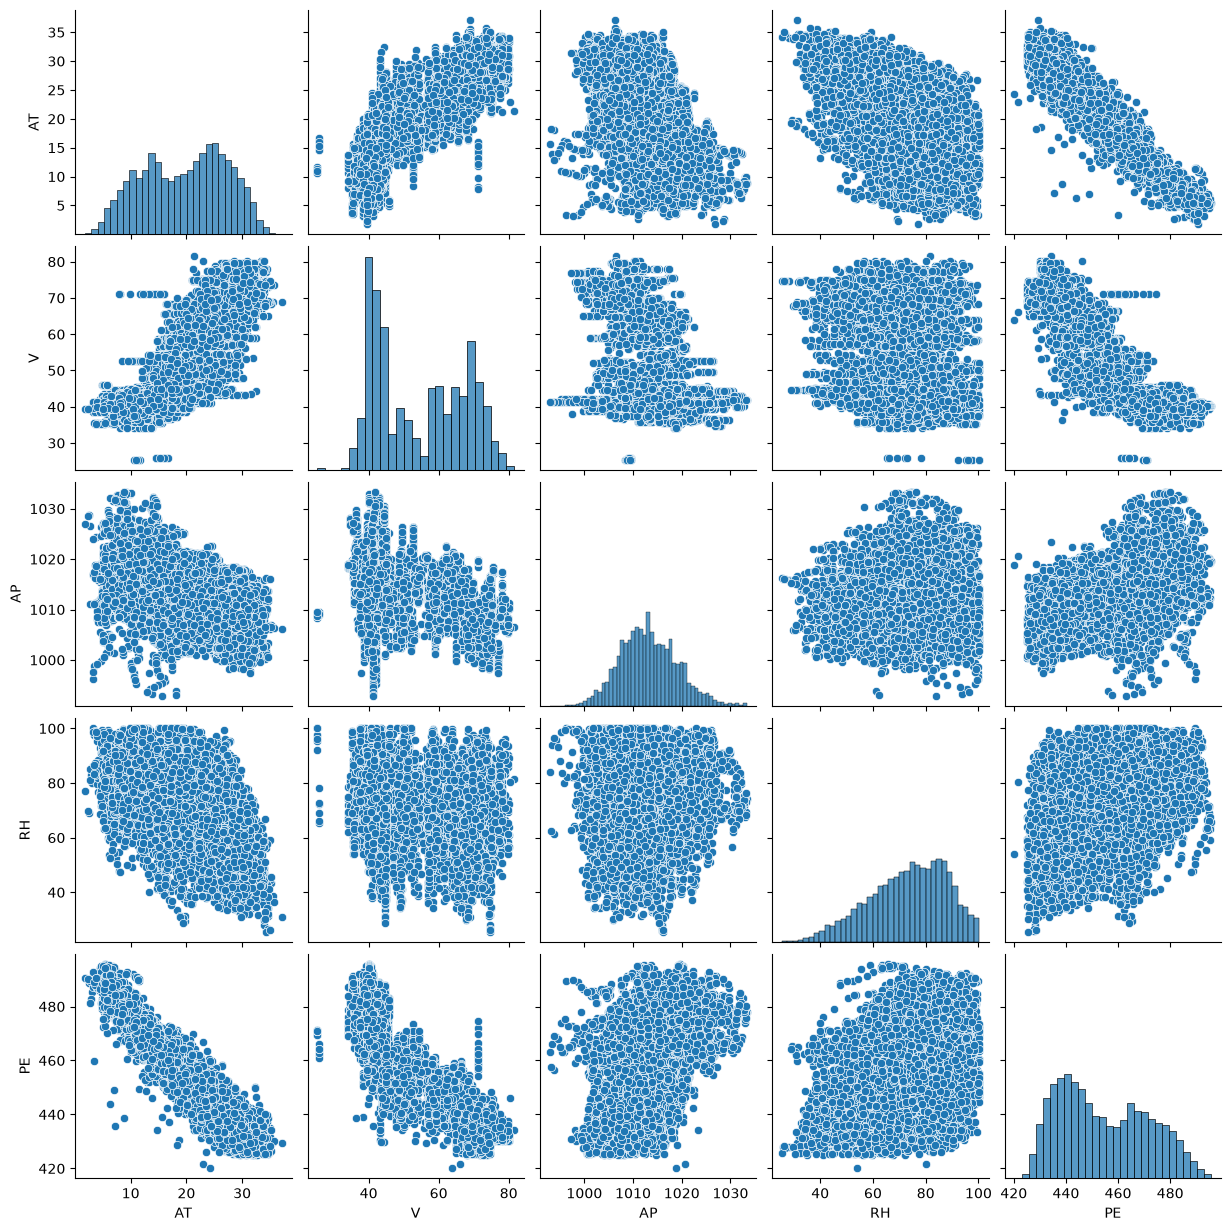

In [11]:
#a pairwise plot 
sns.pairplot(df)
plt.show()

The graph shows the relationships between variables:

AT: A very strong negative relationship. As temperature increases, electrical power output generally decreases. This shows a strong negative relationship.

V: V also appears to have a negative relationship with PE. The relationship does seem less linear than AT and PE.

AP: AP seems to have a positive but weak relationship with PE.

RH: RH also shows a weak positive relationship with PE with lots of scattered points.

There are a few relationships between predictor variables too; AT and V have a positive relationship.

Some of the graphs do contain outliers as well.

AT appears to have the strongest individual relationship with PE.

#### iii. Summary Statistics

In [12]:
#the stats summary
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary.round(2)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression

In [15]:
# List of the predictors
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}

# making a linear regression model for each predictor
for predictor in predictors:
    #the independent variable
    X = df[[predictor]]
    #adding the constant value
    X = sm.add_constant(X)
    #the dependent variable
    y = df["PE"]
    
    #creates and fits the regression model
    model = sm.OLS(y, X).fit()
    #save the model to the dict
    simple_models[predictor] = model

    print(f"Simple Linear Regression: PE ~ {predictor}")
    #prints the summary
    print(model.summary())
    print("\n")

Simple Linear Regression: PE ~ AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:10:49   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0

#### Simple Linear Regression Results

All four predictors have statistically significant associations with PE because their p-values are less than 0.05.

- **AT:** The coefficient is -2.1713 with an R-squared of 0.899. This indicates a strong negative association between AT and PE. A one-unit increase in AT is associated with an average decrease of approximately 2.17 units in PE. AT alone explains approximately 89.9% of the variation in PE.

- **V:** The coefficient is -1.1681 with an R-squared of 0.757. This indicates a negative association between V and PE. V alone explains approximately 75.7% of the variation in PE.

- **AP:** The coefficient is 1.4899 with an R-squared of 0.269. This indicates a positive association between AP and PE, although the relationship is considerably weaker than those for AT and V.

- **RH:** The coefficient is 0.4557 with an R-squared of 0.152. This indicates a positive association between RH and PE. It has the weakest individual linear relationship with PE among the four predictors.

Therefore, we reject the null hypothesis that the slope coefficient is zero for each of AT, V, AP, and RH.

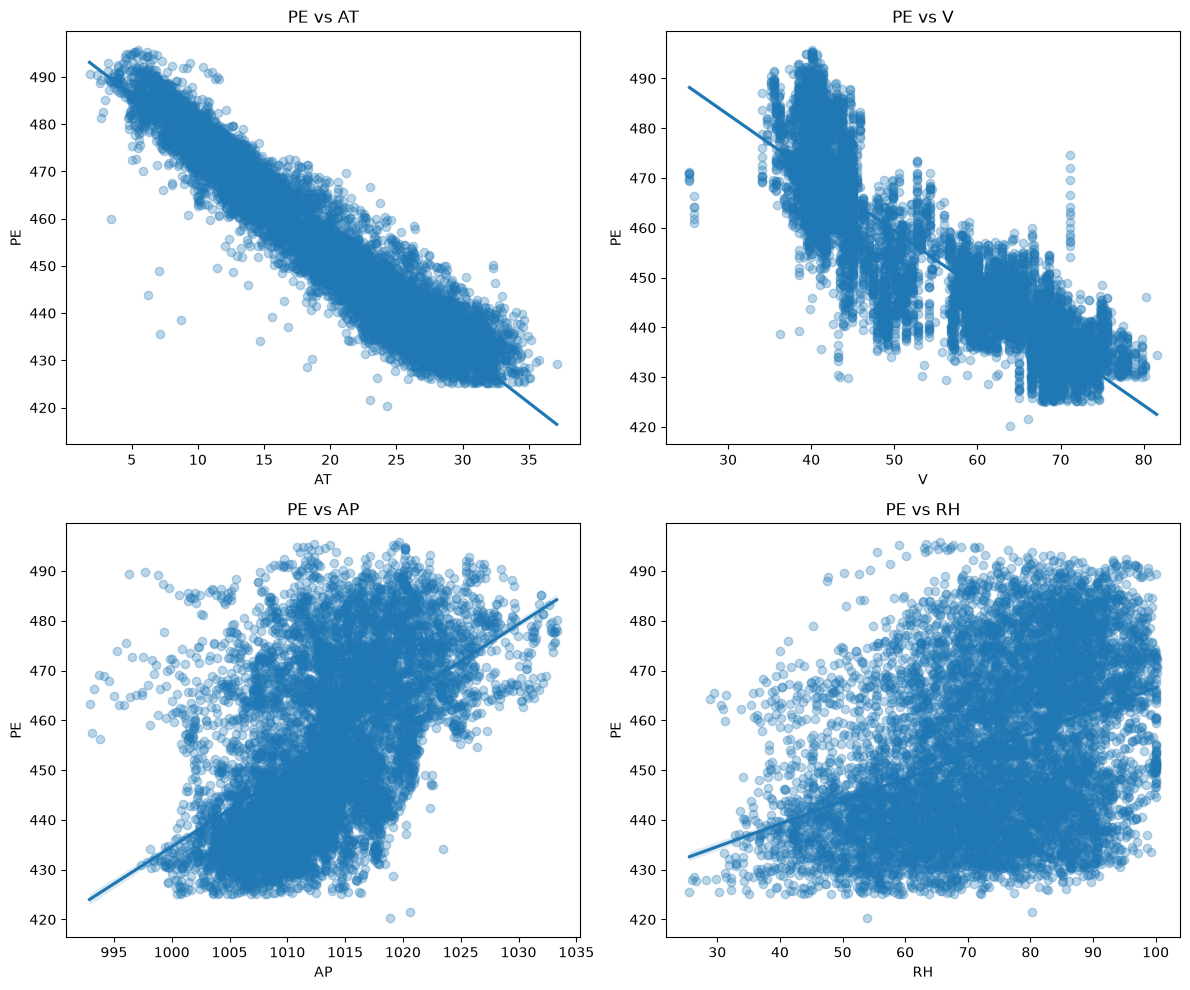

In [16]:
#making a 2x2 grid and divided the screen into 4 areas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    #creates the regssion plot and the scatterplot of obs
    sns. regplot(
        x=predictor,
        y="PE",
        data=df,
        ax=ax,
        scatter_kws={"alpha": 0.3}
    )
    ax.set_title(f"PE vs {predictor}")

plt.tight_layout()
plt.show()

#### Outlier and Influence Analysis

In [9]:
for predictor in predictors:
    
    #getting the saved model
    
    model = simple_models[predictor]
    
    influence = model.get_influence()
    
    #calculates residuals
    
    student_resid = influence.resid_studentized_external
    
    #finds large residuals
    
    outliers = np.where(np.abs(student_resid) > 3)[0]
    
    print(f"{predictor}: {len(outliers)} potential outliers")

AT: 42 potential outliers
V: 33 potential outliers
AP: 30 potential outliers
RH: 2 potential outliers


The studentized residual analysis identified 42 potential outliers for the AT model, 33 for the V model, 30 for the AP model, and 2 for the RH model using the criterion |studentized residual| > 3.

These observations are potential outliers, they represent only a small portion of the 9,568 observations. There is also no evidence that they are measurement or data-entry errors. Therefore, I would not automatically remove these observations.

### (d) Multiple Linear Regression

In [10]:
X = df[["AT", "V", "AP", "RH"]]
X = sm.add_constant(X)

y = df["PE"]

multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:41:04   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

#### Multiple Linear Regression Results

The R-squared is 0.929, showing that approximately 92.9% of the variation in PE is explained by the four predictors together.

The estimated coefficients are:

- AT: -1.9775
- V: -0.2339
- AP: 0.0621
- RH: -0.1581

All four predictors have p-values less than 0.001. Therefore, at a significance level of 0.05, we reject the null hypothesis H0: βj = 0 for AT, V, AP, and RH. Each predictor has a statistically significant association with PE .

### (e) Comparison of Simple and Multiple Regression Coefficients

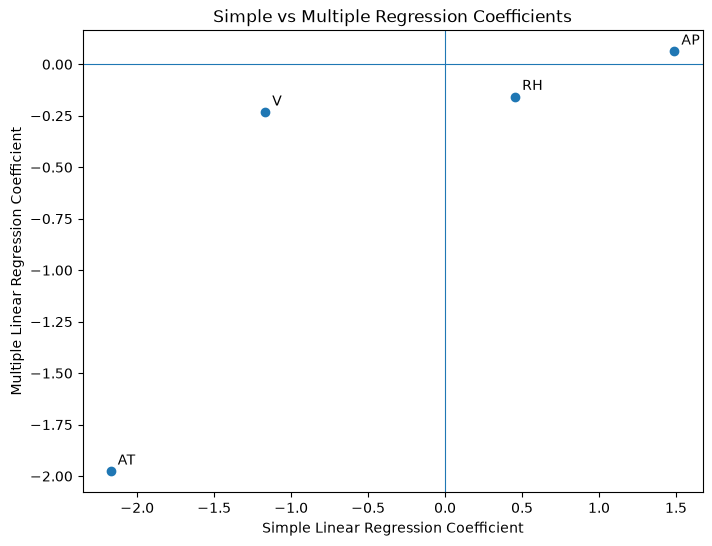

In [11]:
simple_coefs = [simple_models[p].params[p] for p in predictors]
multiple_coefs = [multiple_model.params[p] for p in predictors]

# create the plot
plt.figure(figsize=(8, 6))

# comparing simple vs multiple regression coefficients
plt.scatter(simple_coefs, multiple_coefs)

for i, predictor in enumerate(predictors):
    plt.annotate(
        predictor,
        (simple_coefs[i], multiple_coefs[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Simple Linear Regression Coefficient")
plt.ylabel("Multiple Linear Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficients")

# add reference lines at zero
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.show()

#### Comparison of Results

- **AT:** The coefficient changes from -2.1713 in simple regression to -1.9775 in multiple regression. The relationship remains strongly negative.
- **V:** The coefficient changes from -1.1681 to -0.2339. The relationship remains negative, but its size becomes smaller after adding the other predictors.
- **AP:** The coefficient changes from 1.4899 to 0.0621. The relationship remains positive, but its magnitude becomes much smaller.
- **RH:** The coefficient changes from 0.4557 to -0.1581. The sign of the coefficient changes from positive to negative.

All four predictors remain statistically significant in the multiple regression model, although their estimated coefficients differ substantially from their simple regression coefficients.

### (f) Nonlinear Associations

In [12]:
for predictor in predictors:
    X_poly = pd.DataFrame({
        predictor: df[predictor],
        f"{predictor}^2": df[predictor] ** 2,
        f"{predictor}^3": df[predictor] ** 3
    })

    X_poly = sm.add_constant(X_poly)
    y = df["PE"]

    poly_model = sm.OLS(y, X_poly).fit()

    print(f"Cubic Regression: PE ~ {predictor} + {predictor}^2 + {predictor}^3")
    print(poly_model.summary())
    print("\n")

Cubic Regression: PE ~ AT + AT^2 + AT^3
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:41:04   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

/var/folders/zt/_8tdb1h51t94t6g9s19vr8xc0000gn/T/ipykernel_25370/3673697859.py:11: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  poly_model = sm.OLS(y, X_poly).fit()


### Interpretation

There is evidence of nonlinear association between the predictors and PE.

- **AT:** Both the quadratic and cubic terms are statistically significant (p < 0.05), providing strong evidence of a nonlinear relationship between AT and PE. The R-squared increased from approximately 0.899 for the simple linear model to 0.912 for the cubic model.
- **V:** The quadratic term is not statistically significant (p = 0.768), but the cubic term is significant (p = 0.014). Therefore, there is evidence of a nonlinear component in the relationship between V and PE. The R-squared increased from approximately 0.757 to 0.775.
- **AP:** The quadratic and cubic terms are statistically significant (p < 0.05), suggesting a nonlinear relationship between AP and PE. However, the model produced a rank-deficiency warning and a very large condition number. The R-squared increased only slightly from approximately 0.269 to 0.275.
- **RH:** The quadratic term is statistically significant (p < 0.05), providing evidence of a nonlinear relationship between RH and PE. However, the improvement in R-squared is small, from approximately 0.152 to 0.154.

The polynomial regressions provide evidence of nonlinear associations for all four predictors. AT and V show more noticeable improvements in model fit than AP and RH.

In [13]:
# (g) Multiple regression with all pairwise interaction terms

X_interaction = df[["AT", "V", "AP", "RH"]].copy()

# create all pairwise interaction terms
X_interaction["AT:V"] = df["AT"] * df["V"]
X_interaction["AT:AP"] = df["AT"] * df["AP"]
X_interaction["AT:RH"] = df["AT"] * df["RH"]
X_interaction["V:AP"] = df["V"] * df["AP"]
X_interaction["V:RH"] = df["V"] * df["RH"]
X_interaction["AP:RH"] = df["AP"] * df["RH"]

# add intercept
X_interaction = sm.add_constant(X_interaction)

y = df["PE"]

# fit model
interaction_model = sm.OLS(y, X_interaction).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:41:04   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

### (g) Interaction Effects

Using a significance level of 0.05, the following interaction terms are statistically significant:

- **AT:V** (p < 0.001)
- **AT:RH** (p < 0.001)
- **V:AP** (p < 0.001)
- **AP:RH** (p = 0.034)

The interactions **AT:AP** (p = 0.452) and **V:RH** (p = 0.086) are not statistically significant.



In [14]:
# (h) 70/30 train-test split

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

predictors = ["AT", "V", "AP", "RH"]

#creating the train and test spilt
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

Training observations: 6697
Testing observations: 2871


In [15]:
# Model 1: Multiple Linear Regression

# Getting the predictors and adding constant variables
X_train = train_df[predictors]
X_train = sm.add_constant(X_train)

X_test = test_df[predictors]
X_test = sm.add_constant(X_test)

#the response variable
y_train = train_df["PE"]
y_test = test_df["PE"]

#train the multiple linear regression model
linear_model = sm.OLS(y_train, X_train).fit()

#predicting train and test
train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)

linear_train_mse = mean_squared_error(y_train, train_pred)
linear_test_mse = mean_squared_error(y_test, test_pred)

print("Multiple Linear Regression")
print("Train MSE:", linear_train_mse)
print("Test MSE:", linear_test_mse)

Multiple Linear Regression
Train MSE: 20.580839725738695
Test MSE: 21.239856938225444


In [16]:
# Model 2: interactions + quadratic terms

def create_features(data):
    X = data[["AT", "V", "AP", "RH"]].copy()

    # quadratic terms
    X["AT^2"] = data["AT"] ** 2
    X["V^2"] = data["V"] ** 2
    X["AP^2"] = data["AP"] ** 2
    X["RH^2"] = data["RH"] ** 2

    # pairwise interactions
    X["AT:V"] = data["AT"] * data["V"]
    X["AT:AP"] = data["AT"] * data["AP"]
    X["AT:RH"] = data["AT"] * data["RH"]
    X["V:AP"] = data["V"] * data["AP"]
    X["V:RH"] = data["V"] * data["RH"]
    X["AP:RH"] = data["AP"] * data["RH"]

    return X


X_train_full = create_features(train_df)
X_train_full = sm.add_constant(X_train_full)

full_model = sm.OLS(y_train, X_train_full).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:45:13   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7664.9809   1429.568     -5.362      0.0

In [17]:
selected_features = [
    "AT", "V", "AP", "RH",
    "AT^2", "AP^2", "RH^2",
    "AT:V", "AT:RH", "AP:RH"
]

# Training data
X_train_reduced = create_features(train_df)[selected_features]
X_train_reduced = sm.add_constant(X_train_reduced)

# Testing data
X_test_reduced = create_features(test_df)[selected_features]
X_test_reduced = sm.add_constant(X_test_reduced)

# Fitting the model using only training data
reduced_model = sm.OLS(y_train, X_train_reduced).fit()

print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:46:13   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.046e+04   1091.512     -9.581      0.0

In [19]:
from sklearn.metrics import mean_squared_error

# Predictions
train_pred_reduced = reduced_model.predict(X_train_reduced)
test_pred_reduced = reduced_model.predict(X_test_reduced)

# MSE
train_mse_reduced = mean_squared_error(y_train, train_pred_reduced)
test_mse_reduced = mean_squared_error(y_test, test_pred_reduced)

print("Reduced Interaction + Nonlinear Model")
print("Train MSE:", train_mse_reduced)
print("Test MSE:", test_mse_reduced)


Reduced Interaction + Nonlinear Model
Train MSE: 17.91781267118588
Test MSE: 18.694346190805785


### (h) Model Improvement

The original multiple linear regression model produced a training MSE of 20.5808 and a test MSE of 21.2399.

After including all pairwise interaction terms and quadratic nonlinear terms, insignificant terms were removed using a significance level of 0.05 while preserving the hierarchy of interaction terms. The final reduced model contains AT, V, AP, RH, AT², AP², RH², AT:V, AT:RH, and AP:RH.

The reduced model produced a training MSE of 17.9178 and a test MSE of 18.6943.


### (i) KNN Regression


In [21]:
features = ["AT", "V", "AP", "RH"]

X_train_knn = train_df[features]
X_test_knn = test_df[features]

y_train_knn = train_df["PE"]
y_test_knn = test_df["PE"]

# testing k values from 1-100
k_values = range(1, 101)

#storing MSE for every k
raw_train_mse = []
raw_test_mse = []

# training a KNN model
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_knn, y_train_knn)
    
    # predict train and test
    train_pred = knn.predict(X_train_knn)
    test_pred = knn.predict(X_test_knn)
    
     # calculate and store MSE
    raw_train_mse.append(
        mean_squared_error(y_train_knn, train_pred)
    )

    raw_test_mse.append(
        mean_squared_error(y_test_knn, test_pred)
    )

best_k_raw = k_values[np.argmin(raw_test_mse)]

print("Best k for raw features:", best_k_raw)
print("Best raw training MSE:", raw_train_mse[best_k_raw - 1])
print("Best raw test MSE:", raw_test_mse[best_k_raw - 1])

Best k for raw features: 5
Best raw training MSE: 10.600768887561596
Best raw test MSE: 15.726819842563568


In [22]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_knn)
X_test_scaled = scaler.transform(X_test_knn)

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_scaled, y_train_knn)

    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)

    normalized_train_mse.append(
        mean_squared_error(y_train_knn, train_pred)
    )

    normalized_test_mse.append(
        mean_squared_error(y_test_knn, test_pred)
    )

best_k_normalized = k_values[np.argmin(normalized_test_mse)]

print("Best k for normalized features:", best_k_normalized)
print("Best normalized training MSE:",
      normalized_train_mse[best_k_normalized - 1])
print("Best normalized test MSE:",
      normalized_test_mse[best_k_normalized - 1])

Best k for normalized features: 4
Best normalized training MSE: 8.591432839331045
Best normalized test MSE: 14.305669422675024


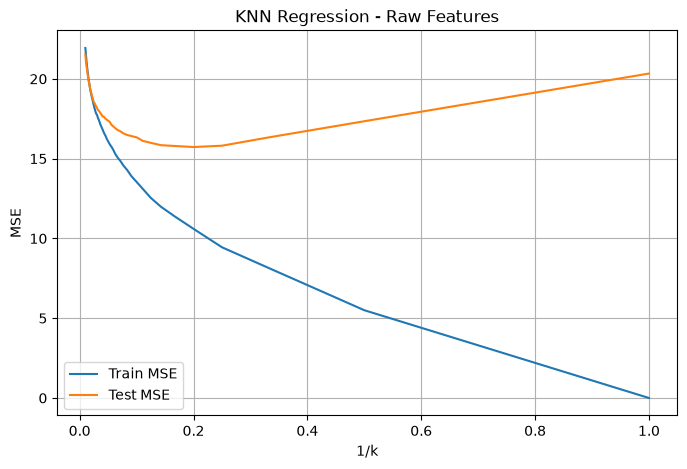

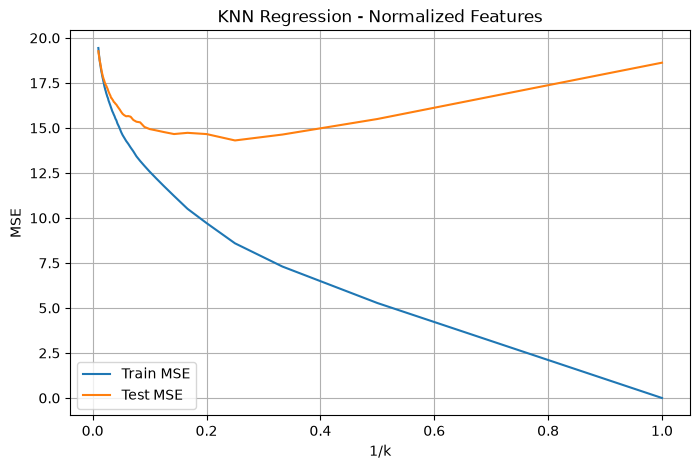

In [23]:

inverse_k = 1 / np.array(list(k_values))

# Raw features
plt.figure(figsize=(8, 5))

plt.plot(inverse_k, raw_train_mse, label="Train MSE")
plt.plot(inverse_k, raw_test_mse, label="Test MSE")

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression - Raw Features")
plt.legend()
plt.grid(True)

plt.show()


# Normalized features
plt.figure(figsize=(8, 5))

plt.plot(inverse_k, normalized_train_mse, label="Train MSE")
plt.plot(inverse_k, normalized_test_mse, label="Test MSE")

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression - Normalized Features")
plt.legend()
plt.grid(True)

plt.show()

### (j) Comparison of KNN and Linear Regression

The best linear regression model from part (h) had a training MSE of 17.9178 and a test MSE of 18.6943.

The best KNN regression model used normalized predictors with $k=4$. It had a training MSE of 8.5914 and a test MSE of 14.3057.

The normalized KNN model achieved a lower test MSE than the best linear regression model (14.3057 compared with 18.6943). 

The improvement tells us that the relationship between predictors and PE may contain some patterns that might be missed by the linear regression model, which the KNN model does not miss.

## Question 2

### (a)
A **flexible method performs better**.

A flexible method performs better because the main issue with flexible methods is the risk of overfitting, but when n is extremely large, the risk of overfitting is less because we have many examples to understand the relationship. And because p is small, we do not have to worry about thousands of variables either. A flexible model can find patterns much more easily than a simple model could.


### (b)
A **flexible method performs worse**.

A flexible method performs worse because when p is big and n is small, it might find some accidental patterns because the dataset is small. Also, when p is that big, there are high chances of it finding meaningless patterns from a pool of variables, which would cause overfitting. The training error might be small, but the test error might be huge, which is a sign of high variance. An inflexible model, on the other hand, puts more restrictions on what it learns about the relationship and does not learn random patterns.

### (c)
A **flexible method performs better**.

The relationship between X and Y is non-linear, which means they would not follow a straight line; there would be some curves along the way, and it would be much harder for an inflexible model to predict that relationship because it would be restricted to just a straight line (causing underfitting) and would not be able to predict the true relationship between X and Y. On the other hand, a flexible model could follow those curves.

### (d)
A **flexible method performs worse**.

When the variance is high, there is a large amount of variation because of random noise, and the flexible method might try to fit the noise and stray away from the true relationship, which would cause overfitting and high variance. A less flexible method would be preferable.

## Question 3

### (a)

Compute the Euclidean distance between each observation and the test point $X_1 = X_2 = X_3 = 0$.

In [3]:
import numpy as np
import pandas as pd

# training data
data = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
}, index=[1, 2, 3, 4, 5, 6])

data

,X1,X2,X3,Y
1,0,3,0,Red
2,2,0,0,Red
3,0,1,3,Red
4,0,1,2,Green
5,-1,0,1,Green
6,1,1,1,Red


In [4]:
# test point
test_point = np.array([0, 0, 0])

# calculating Euclidean distance for each observation
data["Distance"] = np.sqrt(
    (data["X1"] - test_point[0])**2 +
    (data["X2"] - test_point[1])**2 +
    (data["X3"] - test_point[2])**2
)

data

,X1,X2,X3,Y,Distance
1,0,3,0,Red,3.000000
2,2,0,0,Red,2.000000
3,0,1,3,Red,3.162278
4,0,1,2,Green,2.236068
5,-1,0,1,Green,1.414214
6,1,1,1,Red,1.732051


### (b)

For K=1, the prediction is Green because the closest observation to (0,0,0) is Observation 5, with a distance of 1.414. Since Observation 5 belongs to class Green, K=1 is also class Green.

### (c)

For K=3, the prediction is Red because the three smallest distances are Observation 5 (Green), Observation 6 (Red), and Observation 2 (Red).
Since 2 out of 3 nearest neighbours are Red, the prediction for K=3 is also Red.